Nome: Laura Vieira Malachias

RA:299117

Curso: Mestrado em Tecnologia



# Ex05 - Classificação de imagens usando rede neural convolucional (CNN)

O objetivo principal deste notebook é ilustrar e praticar o uso de redes neurais convolucionais (CNNs) para tarefas de classificação de imagens. Em relação às redes neurais convencionais, as CNNs geralmente apresentam a vantagem de possuir menos parâmetros a serem aprendidos. Além disso, as CNNs são particularmente adequadas para trabalhar com imagens devido à sua arquitetura projetada para lidar com dados espaciais de forma eficiente.

Tomaremos como base a biblioteca PyTorch, que segue uma abordagem de programação orientada a objetos. Além dela, recomendamos o uso de outras bibliotecas relacionadas (como o PyTorch Lightning) que auxiliam e simplificam etapas do framework. Note que algumas destas bibliotecas podem não estar disponíveis por padrão no Colab ou sua máquina, sendo necessária sua instalação (como exemplificado na próxima célula de código).

Para mais informações sobre redes convolucionais, exemplos e boas práticas, recomendamos os materiais de apoio às aulas 5 e 6 disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub, vídeos e links de apoio. Em especial, o tutorial prático de classificação com CNN ([link](https://colab.research.google.com/drive/1uXLYbWwHT8cChAYmexV6QNUi5eI4ITod?usp=sharing)) pode ser de grande ajuda.

**Atenção!** Não se esqueça de utilizar a GPU do Colab (clique em "Ambiente de execução" e "Alterar o tipo de ambiente de execução", selecione a GPU).

In [2]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist

In [3]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [4]:
torch.set_float32_matmul_precision('medium')

## Parte 1 - Exemplo de classificação com o MNIST

Exemplificaremos algumas das etapas do framework de classificação com CNN utilizando o conjunto de dados MNIST (Modified National Institute of Standards and Technology database), um grande conjunto de dados de dígitos manuscritos comumente usado na área de aprendizado de máquina. Ele consiste de 60.000 imagens de treinamento e 10.000 images de teste (que, no nosso exemplo, serão utilizadas para validação). As imagens do conjunto são de 28x28 pixels. Uma descrição completa do conjunto de dados pode ser encontrada [aqui](https://en.wikipedia.org/wiki/MNIST_database).

### Leitura dos dados

Idealmente, códigos para processar amostras de dados devem estar desacoplados do código do treinamento do modelo, facilitando sua legibilidade e modularidade. O PyTorch fornece duas primitivas de dados ([torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) e [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)) que facilitam a leitura, processamento e organização dos dados para entrada no modelo. Mais informações sobre Datasets e DataLoaders podem ser encontradas [aqui](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) e [aqui](https://blog.paperspace.com/dataloaders-abstractions-pytorch/).

In [5]:
# Carregando os dados utilizando torchvision.datasets e convertendo as imagens para tensores
training_data = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=ToTensor()
)
val_data = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=ToTensor() 
)

print(training_data)
print()
print(val_data)
print()
print("*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!")

Dataset MNIST
    Number of datapoints: 60000
    Root location: data_mnist
    Split: Train
    StandardTransform
Transform: ToTensor()

Dataset MNIST
    Number of datapoints: 10000
    Root location: data_mnist
    Split: Test
    StandardTransform
Transform: ToTensor()

*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!


**É sempre importante checar e visualizar os dados a cada etapa do framework de classificação, garantindo que eles estão de acordo com o esperado e evitando a propagação de erros.**

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 5
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


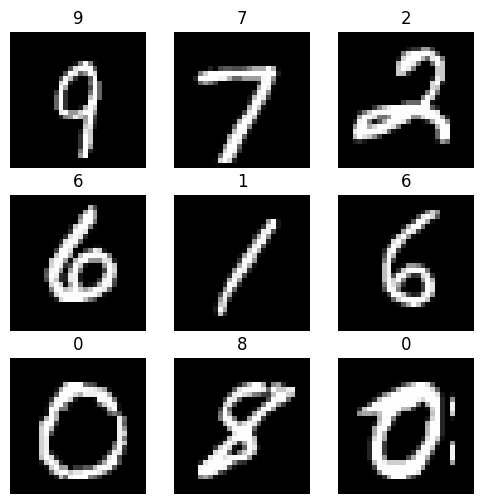

In [6]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(training_data)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(training_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 5
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


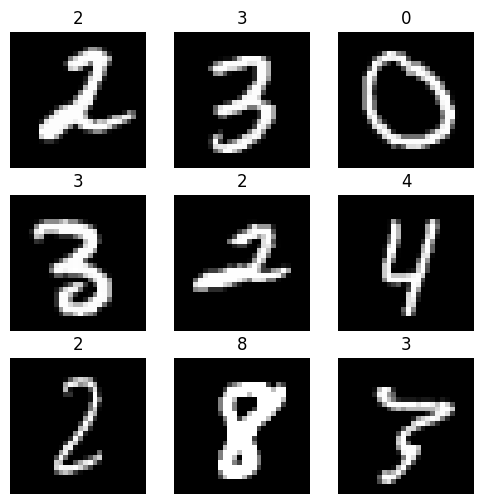

In [7]:
# Checando informações de uma amostra de validação
val_example = random.choice(val_data)
print(len(val_example))
print(type(val_example[0]), type(val_example[1]))
print('Shape da imagem:', val_example[0].shape)
print('Label:', val_example[1])
print('Maior valor de intensidade da imagem:', torch.max(val_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(val_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(val_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

### Exercício 1.1

In [8]:
mnist_raw = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=False,
    transform=None 
)

img_raw, label = mnist_raw[0]
print(type(img_raw))   
print(img_raw.mode)   
print(img_raw.size)    

<class 'PIL.Image.Image'>
L
(28, 28)


Shape sem .squeeze
torch.Size([1, 28, 28])
-----------------------
Shape com .squeeze
torch.Size([28, 28])
-----------------------
Shape com .permute
torch.Size([28, 28, 1])
Erro
Invalid shape (1, 28, 28) for image data


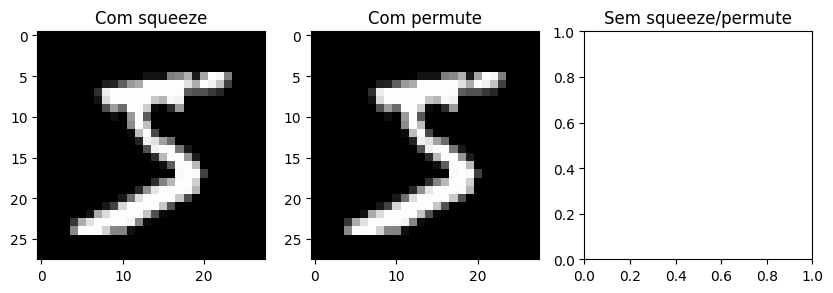

In [9]:
img, label = training_data[0]
img_per = img.permute(1, 2, 0)

print("Shape sem .squeeze")
print(img.shape)   
print("-----------------------")
print("Shape com .squeeze")
print(img.squeeze().shape)
print("-----------------------")
print("Shape com .permute")
print(img_per.shape)

plt.figure(figsize=(10,3))

# funciona
plt.subplot(1,3,1)
plt.title("Com squeeze")
plt.imshow(img.squeeze(), cmap='gray')

#funciona
plt.subplot(1,3,2)
plt.title("Com permute")
plt.imshow(img_per, cmap='gray')

# ERRO
plt.subplot(1,3,3)
plt.title("Sem squeeze/permute")

try:
    plt.imshow(img, cmap='gray')
except Exception as e:
    print("Erro")
    print(e)

plt.show()

Explique o processamento aplicado pela classe torchvision.transforms.ToTensor às imagens do conjunto. Explique também porque foi necessário utilizar o .squeeze() para visualizar as imagens e qual a sua função.

**RESPOSTA**:

A transformação `ToTensor` realiza duas operações sequênciais. Primeiro converte a imagem original para um tensor PyTorch com valores em float e depois reorganiza a ordem das dimensões. 

Ao printar imagem original [0] antes do uso de `ToTensor`, podemos ver que é um objeto PIL, em grayscale (L) e tamanho (28,28) - width, height, chanel (W, H, C). Imagens PIL armazenam pixels no intervalo de [0,255], contudo, valores grandes dificultam a convergência de gradientes nas redes neurais. Sendo assim, é interessante a conversão desses valores para valores discretos (float32) e posteriormente realizar uma normalização de modo que o intervalo seja [0.0, 1.0]. 

A segunda operação, é a reoordeação dos eixos. Como dito anteriormente, em PIL o formato é largura, altura, canal (W,H,C), no entanto, o pytorch opera com tensores no formato canal, altura, largura (C,H,W). Desse modo, a segunda operação feita pelo `ToTensor`é a transposição desses eixos.

Por fim, o `.sequeeze()` é usado para visualizar a imagem no `imshow` do matplotlib. A função imshow espera imagens no formato (H,W,C) ou (H,W), dependendo de a imagem ser colorida ou escala cinza. Contudo, o `ToTensor` acaba de converter de (W,H,C) para (C,H,W), então, o .squeeze entra com a função de mitigar essa conversão removendo todas as dimensões de tamanho 1 do tensor. Então, o que antes era (1,28,28) agora se torna apenas (28,28). 
Podeeríamos usar o `.permute()` para resolver esse problema manualmente, mas o `.squeeze` traz maior praticidade.

Referências:

[Matplotlib. matplotlib.pyplot.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)

[PIL. Image module](https://pillow.readthedocs.io/en/stable/reference/Image.html)

[PyTorch. torchvision.transforms.ToTensor.](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html)

### Hiperparâmetros

É interessante utilizar um dicionário de hiperparâmetros para organizar o código, evitar "números mágicos" e registrar as configurações de cada experimento realizado.

In [10]:
hparams = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 100,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 10,  # number of classes
           "nin": 1,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 10
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


### Data Module

A classe [pytorch_lightning.LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) pode ser utilizada para organizar os DataLoaders e os dados.

In [11]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = training_data
        self.val = val_data

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

**Novamente, checamos os dados obtidos através do DataModule.**

/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Shape do batch: torch.Size([100, 1, 28, 28])


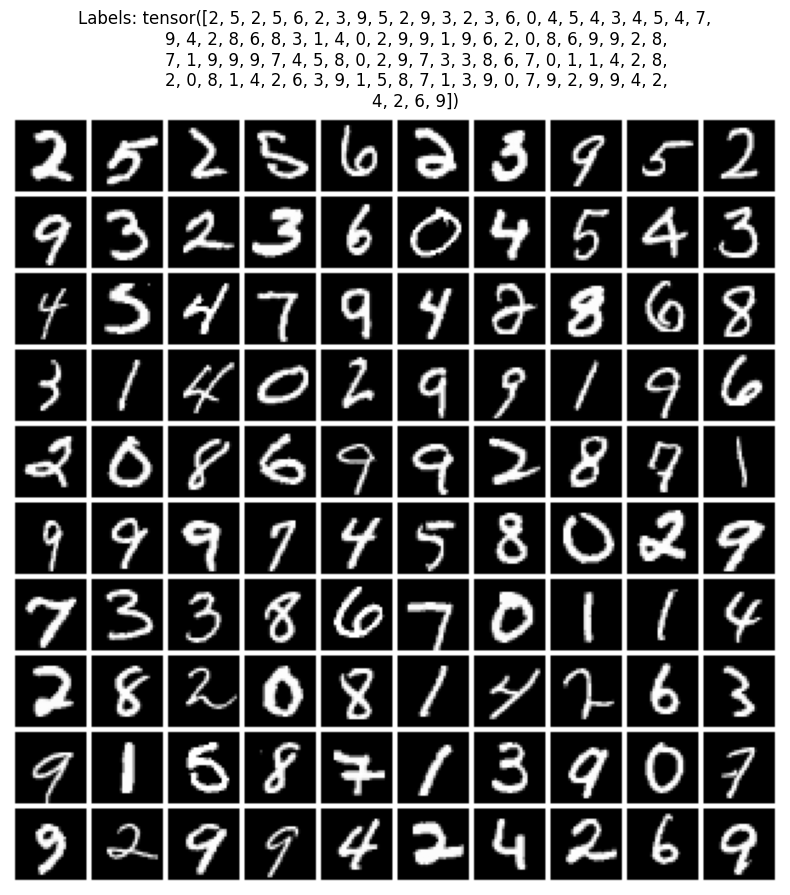

In [12]:
# DEBUG DATA MODULE
data_module = MNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

### Definindo a CNN

No código abaixo, é criado um modelo baseado na [Resnet-18](https://pytorch.org/vision/master/models/generated/torchvision.models.resnet18.html). O mesmo será treinado **sem transfer learning** e com uma inicialização randômica dos pesos. Visualizamos também todas as camadas (layers) que compõem o modelo e seus parâmetros.

In [13]:
cnn_model = models.resnet18(weights=None)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
cnn_model.conv1 = nn.Conv2d(hparams['nin'], 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])
print(cnn_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Exercício 1.2

Para que serve cada camada da rede? Por que foi necessário modificar ligeiramente a rede (célula anterior) e que modificações foram realizadas?

**RESPOSTA:**

**conv1 (Conv2d):** primeira camada convolucional, responsável por extrair características de baixo nível da imagem, como bordas, gradientes e texturas simples. Aplica 64 filtros de tamanho 7×7 com stride 2, o que já reduz pela metade as dimensões espaciais.

**bn1 (BatchNorm2d):** Batch Normalization, que normaliza as ativações dentro de cada mini-batch. Isso reduz o problema de *internal covariate shift*, estabiliza o treinamento e permite o uso de taxas de aprendizado maiores sem divergência.

**relu (ReLU):** função de ativação não-linear, responsável por introduzir não-linearidade na rede. Sem ela, a rede seria equivalente a uma única transformação linear independentemente da profundidade. A ReLU zera os valores negativos e mantém os positivos, sendo computacionalmente eficiente.

**maxpool (MaxPool2d):** camada de *pooling* que reduz as dimensões espaciais por um fator de 2, selecionando o valor máximo em cada janela 3×3. Isso reduz o custo computacional das camadas seguintes e adiciona uma certa invariância a pequenas translações.

**layer1 a layer4 (BasicBlocks):** Cada estágio contém dois BasicBlocks. Dentro de cada BasicBlock há duas camadas Conv2d 3×3 com BatchNorm e ReLU, além de uma conexão residual que soma a entrada diretamente à saída do bloco. Essa conexão permite que o gradiente flua diretamente pela rede durante o retropropagação, viabilizando o treinamento de redes muito profundas sem o problema do *vanishing gradient*. Nos estágios em que a dimensão dos canais dobra (ex: layer2, layer3, layer4), um downsample 1×1 é aplicado na conexão residual para compatibilizar as dimensões.

**avgpool (AdaptiveAvgPool2d):** realiza um *global average pooling*, tranformando cada mapa de características para um único valor, de modo que, isso elimina a dependência do tamanho espacial da entrada e reduz drasticamente o número de parâmetros na camada final.

- **fc (Linear):** camada totalmente conectada que mapeia os 512 features extraídos para o número de classes de saída. 

**Modificações realizadas:**

Foram necessárias duas modificações para adaptar a ResNet-18 padrão ao dataset MNIST:

1. `cnn_model.conv1 = nn.Conv2d(1, 64, [...])`: a ResNet-18 foi projetada para imagens RGB (3 canais). As imagens do MNIST são em escala de cinza (1 canal), portanto o número de canais de entrada foi alterado de 3 para 1.

2. `cnn_model.fc = nn.Linear(512, 10)`: originalmente, a ResNet-18 foi treinada para o ImageNet, que possui 1.000 classes. O MNIST possui apenas 10 classes (dígitos 0 a 9), então a camada de saída foi redimensionada para produzir 10 logits.

Referências:

PyTorch. [Resnet-18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html)

Goodfellow, I., Bengio, Y., & Courville, A. (2016). [Deep Learning.Capítulo 9 — Convolutional Networks.](https://www.deeplearningbook.org/contents/convnets.html)

Zhang, A., Lipton, Z., Li, M., & Smola, A. (2023).[Dive into Deep Learning.](https://d2l.ai/chapter_convolutional-neural-networks/conv-layer.html)

Karpathy, A.[CS231n: Convolutional Neural Networks for Visual Recognition.](https://cs231n.github.io/convolutional-networks/)



### Resumo do modelo

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(device)
cnn_model.to(device)
summary(cnn_model, (1, 28, 28))

mps
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            --
|

### Exercício 1.3

Tente entender as dimensões da saída de cada camada da rede. Por exemplo, porque as três primeiras camadas possuem saídas com dimensões (-1, 64, 14, 14) e a quarta camada tem saída com dimensões (-1, 64, 7, 7)?

E quanto aos parâmetros a serem aprendidos, você consegue explicar como eles são calculados?

**RESPOSTA:**

**Dimensões das saídas**

A fórmula geral para calcular a dimensão espacial da saída de uma convolução 2D é:

$$H_{out} = \left\lfloor \frac{H_{in} + 2 \cdot p - k}{s} \right\rfloor + 1$$

onde $H_{in}$ é a dimensão de entrada, $p$ é o padding, $k$ é o kernel size e $s$ é o stride. A entrada do modelo MNIST tem shape `(batch, 1, 28, 28)`.

**conv1** (kernel=7, stride=2, padding=3):
$$H_{out} = \left\lfloor \frac{28 + 2 \cdot 3 - 7}{2} \right\rfloor + 1 = \left\lfloor \frac{27}{2} \right\rfloor + 1 = 13 + 1 = 14$$
Saída: `(-1, 64, 14, 14)`. O BatchNorm2d (bn1) e o ReLU não alteram as dimensões espaciais, por isso as três primeiras camadas mantêm o mesmo shape.

**maxpool** (kernel=3, stride=2, padding=1):
$$H_{out} = \left\lfloor \frac{14 + 2 \cdot 1 - 3}{2} \right\rfloor + 1 = \left\lfloor \frac{13}{2} \right\rfloor + 1 = 6 + 1 = 7$$
Saída: `(-1, 64, 7, 7)`. É exatamente o MaxPool que causa essa redução de 14→7, não as camadas de ativação.

**Contagem de parâmetros**

Para camadas convolucionais, o número de parâmetros é: `(C_in × k_h × k_w + bias) × C_out`.

- **conv1** `Conv2d(1, 64, 7, 7, bias=False)`: 1 × 7 × 7 × 64 = **3.136** parâmetros 

- **BatchNorm2d(64)**: aprende um fator de escala (γ) e um deslocamento (β) por canal → 64 × 2 = **128** parâmetros 

- **Conv2d(64, 64, 3, 3, bias=False)** nos BasicBlocks: 64 × 3 × 3 × 64 = **36.864** parâmetros 

- **Linear(512, 10)**: pesos (512 × 10) + bias (10) = **5.130** parâmetros 

O total de ~11,2M de parâmetros é característico da ResNet-18, que é uma arquitetura relativamente compacta para o que oferece em termos de capacidade de representação.


**Referências:**

Goodfellow, I., Bengio, Y., & Courville, A. (2016). [Deep Learning.Capítulo 9 — Convolutional Networks.](https://www.deeplearningbook.org/contents/convnets.html)

Zhang, A., Lipton, Z., Li, M., & Smola, A. (2023).[Dive into Deep Learning.](https://d2l.ai/chapter_convolutional-neural-networks/conv-layer.html)

Karpathy, A.[CS231n: Convolutional Neural Networks for Visual Recognition.](https://cs231n.github.io/convolutional-networks/)

### Lightning Module

Aqui definimos o comportamento durante o treinamento, ou seja, o que acontece com um lote retornado pelo DataLoader.

In [16]:
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

### Treinando a CNN

In [17]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MNISTDataModule(hparams)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Hyperparameters:

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 10
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/laura/Documents/Unicamp/IA901/2026s1-pi05-cnn-Laur4vM/logs exists and is not empty.

  | Name     | Type               | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model    | ResNet             | 11.2 M | train | 0    
1 | loss     | CrossEntropyLoss   | 0      | train | 0    
2 | accuracy | MulticlassAccuracy | 0      | train | 0    
----------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.701    Total estimated model params size (MB)
70        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 9: 100%|██████████| 600/600 [00:15<00:00, 37.50it/s, v_num=29, val_loss=1.470, val_acc=0.987]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 600/600 [00:16<00:00, 37.12it/s, v_num=29, val_loss=1.470, val_acc=0.987]


### Visualizando os logs de treinamento

Por padrão, o Pytorch Lightning registra os resultados do treinamento usando o TensorBoard. Você pode configurar muitos outros registradores (https://pytorch-lightning.readthedocs.io/en/stable/extensions/logging.html), recomendamos verificar o Neptune ou o MLFlow. Utilize esses registradores para comparar experimentos!

Abaixo é possível verificar os resultados do treinamento realizado previamente (disponibilizado no diretório **Dados/Ex05/saved_lightning_logs**).

In [18]:
%tensorboard --logdir lightning_logs

Reusing TensorBoard on port 6006 (pid 75739), started 3 days, 6:24:15 ago. (Use '!kill 75739' to kill it.)

### Análise dos resultados

Após o treinamento da rede, é importante checar os resultados de validação, visualizando algumas saídas da rede e obtendo métricas de classificação. Abaixo exemplificamos a visualização da matriz de confusão.

In [19]:
# WARNING: This will load a random checkpoint from the logs folder, if you want an specific one change it!
baseline_model = random.choice(glob("logs/*.ckpt"))
print(f"Using model {baseline_model}")

device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")

# Load trained model
model = TrainMNIST.load_from_checkpoint(baseline_model).eval().to(device)

# Initialize validation data
data = MNISTDataModule(hparams)
data.setup()
data.hparams.batch_size = 1
val_data = data.val_dataloader()

def collect_2d_results(data, model, device):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.to(device)).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(val_data, model,device)

Using model logs/Test_ResNet_1-epoch=9-val_acc=0.99-v1.ckpt


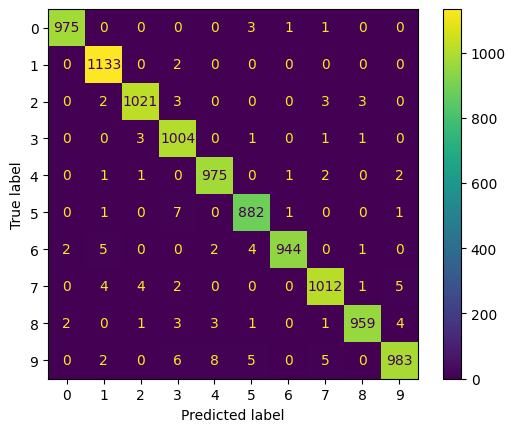

In [20]:
# Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(10)),
                                display_labels=np.arange(10))
fig = disp.plot(ax=None).figure_
plt.show()

Por fim, o modelo final seria avaliado em um conjunto de teste (que não está disponível no exemplo apresentado). **Vale ressaltar que o conjunto de teste não deve ser utilizado para refinar o modelo! Ele deve ser utilizado apenas para uma avaliação final do modelo.**

## Parte 2 - Classificação com o DermaMNIST

Vamos retomar a classificação do dataset de imagens dermatoscópicas de lesões de pele comuns, utilizado no Exercício 02. Desta vez, ao invés de extrair os atributos "artesanalmente" e classificar com o KNN, utilizaremos CNNs para realizar os dois processos simultaneamente (extração de atributos + classificação).

**Dataset**

O dataset consiste em 600 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 300 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 300 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe), um conjunto de validação com 100 imagens (50 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe). As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

### Exercício 2.1

Com base no exemplo apresentado e nos materiais de apoio disponibilizados, treine uma CNN para classificar as lesões de pele. Considere as recomendações abaixo:

- Considere aplicar [transformações](https://pytorch.org/vision/stable/transforms.html) durante a leitura dos dados, seja para normalizá-los ou realizar aumentação de dados.
- Lembre-se de sempre checar os dados!
- Você pode definir sua própria rede ou utilizar modelos de classificação disponibilizados pelo PyTorch (como a [ResNet](https://pytorch.org/vision/stable/models/resnet.html) ou a [EfficientNet](https://pytorch.org/vision/stable/models/efficientnet.html)). Caso utilize modelos disponibilizados, tome cuidado com as entradas e saídas da rede, talvez seja necessário realizar algumas modificações (como no exemplo apresentado). Considere também a utilização de modelos pré-treinados, eles apresentam resultados melhores do que modelos inicializados com pesos randômicos?
- Note que, no exemplo apresentado, os checkpoints da rede e os logs do PyTorch Lightning ficam salvos no ambiente de execução do Colab. Tome cuidado para não acabar perdendo experimentos! Você pode alterar o local em que esses arquivos são salvos para que sejam armazenados no seu Drive ou ainda salvar manualmente os arquivos que julgar importantes.
- Tente modificar os hiperparâmetros para obter melhores resultados de validação.
- Verifique os resultados do modelo: visualize algumas saídas da rede e obtenha métricas de classificação (acurácia, precisão, revocação e F1-score), além de imprimir a matriz de confusão.
- Idealmente, você deve avaliar apenas o modelo final no conjunto de teste.

Comente os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas. Compare também os resultados obtidos através da CNN com os resultados obtidos através do KNN no Exercício 02.

In [21]:
pl.seed_everything(12, workers=True)

#Código base para leitura dos dados
train_dataset_base = DermaMNIST(
    split="train",
    download=True
)

test_dataset_base = DermaMNIST(
    split="test",
    download=True
)

#Train+Val
train_indices_0 = train_dataset_base.labels == 1
train_indices_1 = train_dataset_base.labels == 4

train_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][:200]
train_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][:200]
train_imgs = np.vstack([train_imgs_0, train_imgs_1])

val_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][200:250]
val_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][200:250]
val_imgs = np.vstack([val_imgs_0, val_imgs_1])


#Test
test_indices_0 = test_dataset_base.labels == 1
test_indices_1 = test_dataset_base.labels == 4

test_imgs_0 = test_dataset_base.imgs[test_indices_0.flatten(), :, :, :][:50]
test_imgs_1 = test_dataset_base.imgs[test_indices_1.flatten(), :, :, :][:50]
test_imgs = np.vstack([test_imgs_0, test_imgs_1])

#Labels

train_labels = np.zeros(400)
train_labels[200:].fill(1)

val_labels = np.zeros(100)
val_labels[50:].fill(1)

test_labels = np.zeros(100)
test_labels[50:].fill(1)

train_dataset = TensorDataset(torch.tensor(train_imgs), torch.tensor(train_labels))
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TensorDataset(torch.tensor(val_imgs), torch.tensor(val_labels))
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=0)

test_dataset = TensorDataset(torch.tensor(test_imgs), torch.tensor(test_labels))
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0)

Seed set to 12


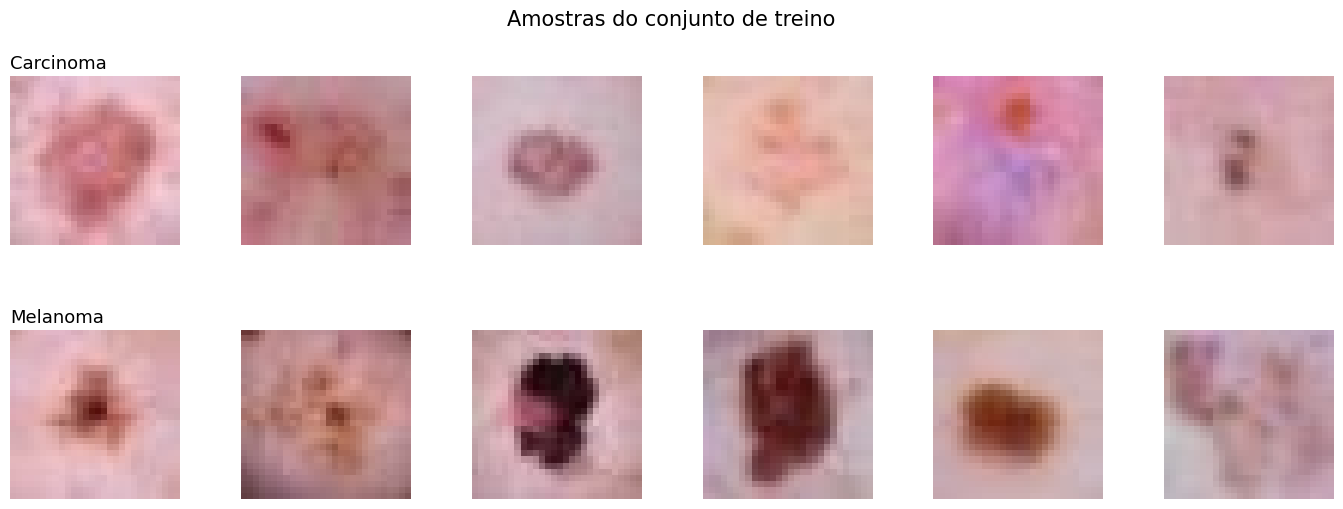

In [22]:
class_names = {0: 'Carcinoma ', 1: 'Melanoma'}

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for cls_idx, cls_label in enumerate([0, 1]):
    idxs = np.where(train_labels == cls_label)[0]
    sample_idxs = np.random.choice(idxs, 6, replace=False)
    for col, idx in enumerate(sample_idxs):
        axes[cls_idx, col].imshow(train_imgs[idx])
        axes[cls_idx, col].axis('off')
        if col == 0:
            axes[cls_idx, col].set_title(class_names[cls_label], loc='left', fontsize=13)

plt.suptitle('Amostras do conjunto de treino', fontsize=15, y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)

plt.show()

In [23]:
from torchvision import datasets, models, transforms

In [24]:
def preprocess(imgs):
    imgs_t = torch.tensor(imgs, dtype=torch.float32) / 255.0  
    imgs_t = imgs_t.permute(0, 3, 1, 2) 
    return imgs_t

train_tensors = preprocess(train_imgs)
val_tensors   = preprocess(val_imgs)
test_tensors  = preprocess(test_imgs)

train_label_tensors = torch.tensor(train_labels, dtype=torch.long)
val_label_tensors   = torch.tensor(val_labels,   dtype=torch.long)
test_label_tensors  = torch.tensor(test_labels,  dtype=torch.long)

print("Train:", train_tensors.shape, train_label_tensors.shape)
print("Val:  ", val_tensors.shape,   val_label_tensors.shape)
print("Test: ", test_tensors.shape,  test_label_tensors.shape)

Train: torch.Size([400, 3, 28, 28]) torch.Size([400])
Val:   torch.Size([100, 3, 28, 28]) torch.Size([100])
Test:  torch.Size([100, 3, 28, 28]) torch.Size([100])


In [25]:
hparams_derma = {
    'experiment_name': 'Derma_ResNet18_v1',
    'max_epochs': 30,
    'batch_size': 32,
    'nworkers': 0,
    'nout': 2,  
    'nin': 3, 
    'lr': 3e-4,
    'wd': 1e-4,
    'cpu': False,
}

In [26]:
class DermaDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.hparams.update(hparams)

    def setup(self, stage=None):
        self.train_dataset = TensorDataset(train_tensors, train_label_tensors)
        self.val_dataset   = TensorDataset(val_tensors,   val_label_tensors)
        self.test_dataset  = TensorDataset(test_tensors,  test_label_tensors)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.hparams.batch_size,
                          shuffle=True,  num_workers=self.hparams.nworkers)

    def val_dataloader(self):
        return DataLoader(self.val_dataset,   batch_size=self.hparams.batch_size,
                          shuffle=False, num_workers=self.hparams.nworkers)

    def test_dataloader(self):
        return DataLoader(self.test_dataset,  batch_size=self.hparams.batch_size,
                          shuffle=False, num_workers=self.hparams.nworkers)

In [27]:
derma_cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = derma_cnn.fc.in_features
derma_cnn.fc = nn.Linear(num_ftrs, hparams_derma['nout']) 

print(derma_cnn)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(device)
derma_cnn.to(device)
summary(derma_cnn, (3, 28, 28))

mps
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          9,408
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          9,408
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            --
|

In [29]:
class TrainDerma(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)
        self.model    = derma_cnn
        self.loss     = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task='binary')

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss  = self.loss(y_hat, y)

        if mode == 'train':
            self.log('loss', loss, on_epoch=True, on_step=True)
            return loss
        elif mode == 'val':
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log('val_loss', loss,          on_epoch=True, on_step=False, prog_bar=True)
            self.log('val_acc',  self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step('train', train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step('val', val_batch)

    def configure_optimizers(self):
        return AdamW(self.model.parameters(),
                     lr=self.hparams.lr, weight_decay=self.hparams.wd)

In [30]:
model_derma = TrainDerma(hparams_derma)
data_derma  = DermaDataModule(hparams_derma)

os.makedirs('logs_derma', exist_ok=True)
checkpoint_callback = [ModelCheckpoint(
    dirpath='logs_derma',
    filename=hparams_derma['experiment_name'] + '-{epoch}-{val_acc:.2f}',
    monitor='val_acc',
    mode='max'
)]

trainer_derma = pl.Trainer(
    max_epochs=hparams_derma['max_epochs'],
    fast_dev_run=False,
    callbacks=checkpoint_callback,
    log_every_n_steps=1,
    deterministic=True
)

print('Hyperparameters:\n')
for k, v in hparams_derma.items():
    print(f'{k}: {v}')

trainer_derma.fit(model_derma, data_derma)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/laura/Documents/Unicamp/IA901/2026s1-pi05-cnn-Laur4vM/logs_derma exists and is not empty.

  | Name     | Type             | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model    | ResNet           | 11.2 M | train | 0    
1 | loss     | CrossEntropyLoss | 0      | train | 0    
2 | accuracy | BinaryAccuracy   | 0      | train | 0    
--------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.710    To

Hyperparameters:

experiment_name: Derma_ResNet18_v1
max_epochs: 30
batch_size: 32
nworkers: 0
nout: 2
nin: 3
lr: 0.0003
wd: 0.0001
cpu: False
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 13/13 [00:00<00:00, 25.08it/s, v_num=30, val_loss=0.437, val_acc=0.860]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 13/13 [00:00<00:00, 24.95it/s, v_num=30, val_loss=0.437, val_acc=0.860]


In [31]:
best_ckpt = sorted(glob('logs_derma/*.ckpt'))[-1]
print(f'Using model {best_ckpt}')

eval_model = TrainDerma.load_from_checkpoint(best_ckpt).eval().to(device)

data_derma.setup()
data_derma.hparams.batch_size = 1
val_loader = data_derma.val_dataloader()

def collect_2d_results(data, model):
    y_trues, y_preds = [], []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.to(device)).argmax(dim=-1).item()
        y_trues.append(label.item())
        y_preds.append(out)
    return y_trues, y_preds

y_true_val, y_pred_val = collect_2d_results(val_loader, eval_model)

Using model logs_derma/Derma_ResNet18_v1-epoch=13-val_acc=0.93.ckpt


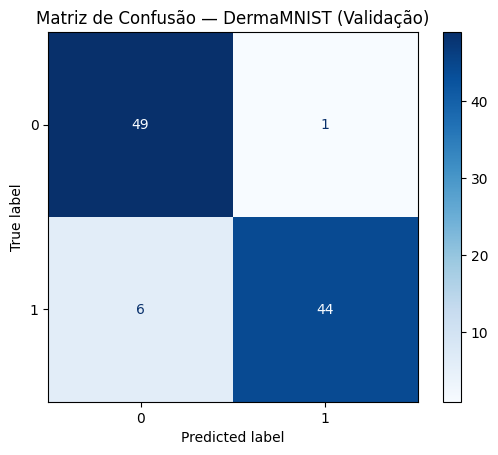

In [32]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_val, y_pred_val, labels=[0, 1]),
    display_labels=class_names
)
fig = disp.plot(cmap='Blues', ax=None).figure_
plt.title('Matriz de Confusão — DermaMNIST (Validação)')
plt.show()

In [33]:
from sklearn.metrics import classification_report

class_names_list = ['Carcinoma ', 'Melanoma']   
print(classification_report(y_true_val, y_pred_val, target_names=class_names_list))

              precision    recall  f1-score   support

  Carcinoma        0.89      0.98      0.93        50
    Melanoma       0.98      0.88      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



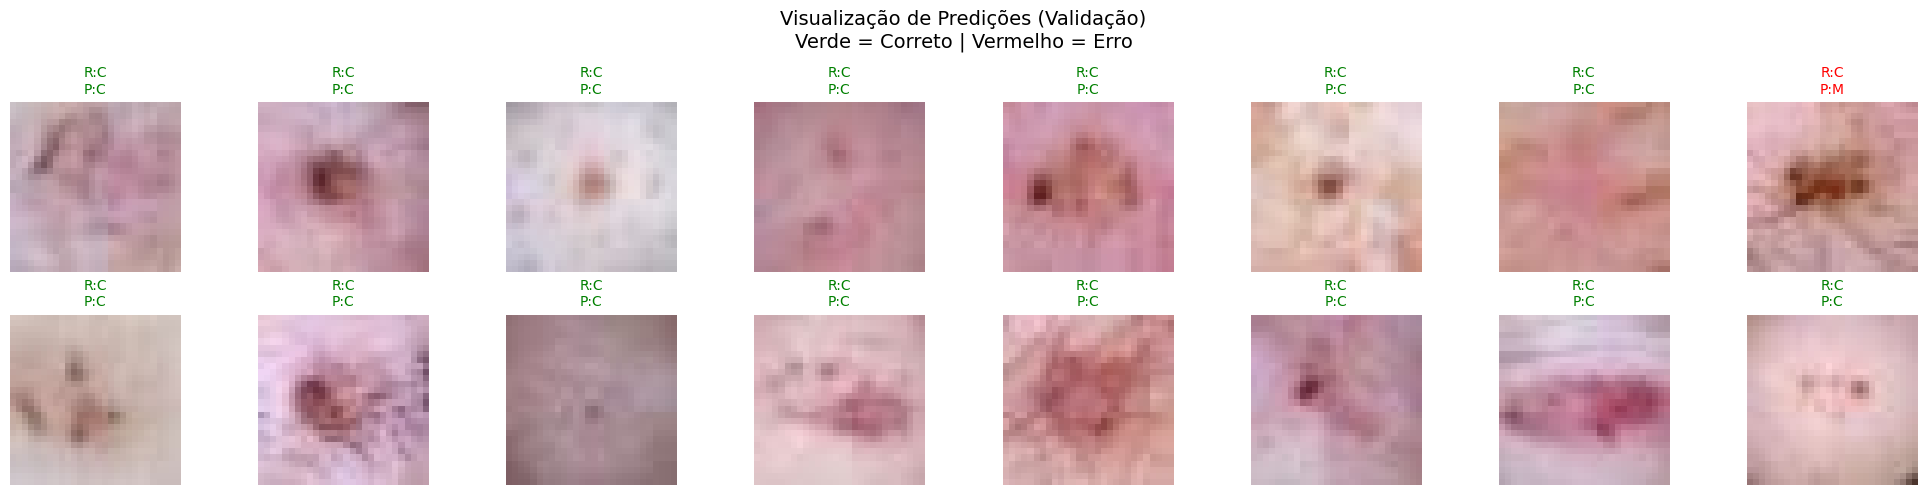

In [34]:
data_derma.hparams.batch_size = hparams_derma['batch_size']
val_loader_vis = data_derma.val_dataloader()

imgs_vis, labels_vis = next(iter(val_loader_vis))
with torch.no_grad():
    preds_vis = eval_model(imgs_vis.to(device)).argmax(dim=-1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
axes = axes.flatten()
for i in range(16):
    img_show = val_imgs[i]   
    true_l   = labels_vis[i].item()
    pred_l   = preds_vis[i].item()
    color    = 'green' if true_l == pred_l else 'red'
    axes[i].imshow(img_show)
    axes[i].set_title(f'R:{class_names[true_l][0]}\nP:{class_names[pred_l][0]}',
                      fontsize=10, color=color)
    axes[i].axis('off')

plt.suptitle('Visualização de Predições (Validação)\nVerde = Correto | Vermelho = Erro', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(hspace=0.25)

plt.show()
#R = Resposta
#P = Predito

Avaliação final no teste

--- Resultado Final---
              precision    recall  f1-score   support

  Carcinoma        0.86      0.98      0.92        50
    Melanoma       0.98      0.84      0.90        50

    accuracy                           0.91       100
   macro avg       0.92      0.91      0.91       100
weighted avg       0.92      0.91      0.91       100



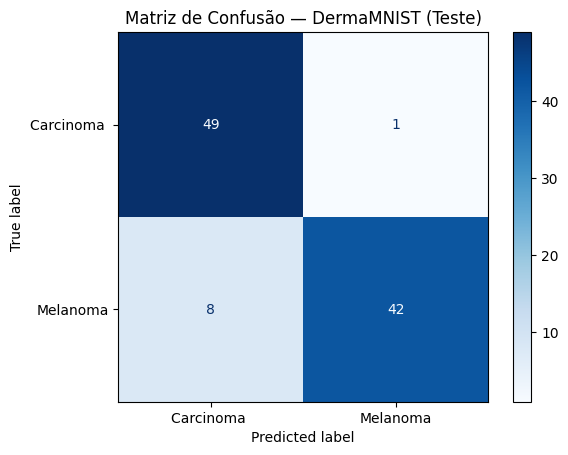

In [35]:
def collect_2d_results(data, model):
    y_trues, y_preds = [], []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.to(device)).argmax(dim=-1)
        y_trues.extend(label.tolist())
        y_preds.extend(out.cpu().tolist())
    return y_trues, y_preds

test_loader = data_derma.test_dataloader()
y_true_test, y_pred_test = collect_2d_results(test_loader, eval_model)

print('--- Resultado Final---')
print(classification_report(y_true_test, y_pred_test, target_names=class_names_list))

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_test, y_pred_test, labels=[0, 1]),
    display_labels=class_names_list
)
disp_test.plot(cmap='Blues') 
plt.title('Matriz de Confusão — DermaMNIST (Teste)')
plt.show()

In [36]:
hparams_derma_scratch = {
    'experiment_name': 'Derma_ResNet18_scratch_v1',
    'max_epochs': 30,
    'batch_size': 32,
    'nworkers': 0,
    'nout': 2,
    'nin': 3,
    'lr': 3e-4,
    'wd': 1e-4,
    'cpu': False,
}

# Mesma classe TrainDerma, só muda o weights=None
class TrainDermaScratch(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

        derma_cnn_scratch = models.resnet18(weights=None)  # sem pré-treinamento
        num_ftrs = derma_cnn_scratch.fc.in_features
        derma_cnn_scratch.fc = nn.Linear(num_ftrs, hparams['nout'])
        self.model = derma_cnn_scratch

        self.loss     = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task='binary')

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss  = self.loss(y_hat, y)

        if mode == 'train':
            self.log('loss', loss, on_epoch=True, on_step=True)
            return loss
        elif mode == 'val':
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log('val_loss', loss,          on_epoch=True, on_step=False, prog_bar=True)
            self.log('val_acc',  self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step('train', train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step('val', val_batch)

    def configure_optimizers(self):
        return AdamW(self.model.parameters(),
                     lr=self.hparams.lr, weight_decay=self.hparams.wd)

In [37]:
model_scratch = TrainDermaScratch(hparams_derma_scratch)
data_scratch  = DermaDataModule(hparams_derma_scratch)

os.makedirs('logs_derma_scratch', exist_ok=True)
checkpoint_scratch = [ModelCheckpoint(
    dirpath='logs_derma_scratch',
    filename=hparams_derma_scratch['experiment_name'] + '-{epoch}-{val_acc:.2f}',
    monitor='val_acc',
    mode='max'
)]

trainer_scratch = pl.Trainer(
    max_epochs=hparams_derma_scratch['max_epochs'],
    fast_dev_run=False,
    callbacks=checkpoint_scratch,
    log_every_n_steps=1,
)

trainer_scratch.fit(model_scratch, data_scratch)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/laura/Documents/Unicamp/IA901/2026s1-pi05-cnn-Laur4vM/logs_derma_scratch exists and is not empty.

  | Name     | Type             | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model    | ResNet           | 11.2 M | train | 0    
1 | loss     | CrossEntropyLoss | 0      | train | 0    
2 | accuracy | BinaryAccuracy   | 0      | train | 0    
--------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.7

/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 13/13 [00:00<00:00, 24.72it/s, v_num=31, val_loss=0.508, val_acc=0.800]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 13/13 [00:00<00:00, 24.59it/s, v_num=31, val_loss=0.508, val_acc=0.800]


In [38]:
from sklearn.metrics import classification_report, f1_score

best_ckpt_scratch = sorted(glob('logs_derma_scratch/*.ckpt'))[-1]
eval_scratch = TrainDermaScratch.load_from_checkpoint(best_ckpt_scratch).eval().to(device)

data_scratch.setup()
val_loader_scratch = data_scratch.val_dataloader()

y_true_scratch, y_pred_scratch = collect_2d_results(val_loader_scratch, eval_scratch)

print('--- Transfer learning---')
print(classification_report(y_true_val, y_pred_val, target_names=class_names_list))
print(f'F1-score: {f1_score(y_true_val, y_pred_val, average="weighted"):.3f}')

print('--- from Scratch---')
print(classification_report(y_true_scratch, y_pred_scratch, target_names=class_names_list))
print(f'F1-score: {f1_score(y_true_scratch, y_pred_scratch, average="weighted"):.3f}')

--- Transfer learning---
              precision    recall  f1-score   support

  Carcinoma        0.89      0.98      0.93        50
    Melanoma       0.98      0.88      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100

F1-score: 0.930
--- from Scratch---
              precision    recall  f1-score   support

  Carcinoma        0.85      0.92      0.88        50
    Melanoma       0.91      0.84      0.88        50

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100

F1-score: 0.880


### Metodologia usada
Para efeitos comparativos, não apenas com a KNN da Atividade 2, foi feita a comparação com cnn com e sem pré treinamento (Transfer Learning e from Scratch).

As imagens do DermaMNIST são fornecidas como arrays NumPy no formato (N, H, W, C), com valores inteiros no intervalo [0, 255]. Antes de serem usadas pela rede, foi aplicada a normalização dos pixels para [0.0, 1.0], dividindo os valores por 255, e a reordenação dos eixos para (N, C, H, W) usando `.permute()`.

Na ResNet-18, a única modificação foi na camada final: Linear(512 -> 1000) foi substituída por Linear(512 -> 2), adaptando o modelo para classificação binária (carcinoma vs. melanoma). O canal de entrada permaneceu inalterado, pois as imagens do DermaMNIST são RGB (3 canais).

A função de perda utilizada foi CrossEntropyLoss, sem ponderação de classes, já que o dataset é balanceado (200 amostras por classe no treino e 50 por classe na validação e no teste). O otimizador escolhido foi AdamW, com learning rate de 3e-4 e weight decay de 1e-4. O AdamW aplica o weight decay de forma desacoplada do gradiente, funcionando como uma regularização L2 e ajudando a reduzir overfitting em datasets pequenos.

Durante o treinamento foi monitorada a acurácia de validação (val_acc). Ao final, também foram calculadas precisão, revocação e F1-score por classe. O modelo final foi selecionado com base no melhor val_acc ao longo das épocas, salvo automaticamente com `ModelCheckpoint`.

### Análise dos resultados
A análise mostra que usar Transfer Learning com a arquitetura ResNet18 foi a estratégia que funcionou melhor, pois esse método teve desempenho superior ao treinamento feito from scratch em todas as métricas principais. Enquanto o modelo treinado com pesos aleatórios chegou a 88% de acurácia, o modelo pré-treinado na ImageNet alcançou 93% de acurácia e F1-score de 0,93. Isso indica que aproveitar um modelo já treinado ajuda bastante, porque ele já reconhece padrões visuais básicos, o que facilita a generalização quando o conjunto de dados médicos é pequeno.

Analisando o desempenho por classe, o modelo teve resultados bem estáveis na identificação de Carcinoma, alcançando 98% de recall no conjunto de teste. Já a classe Melanoma foi mais difícil de classificar: o recall caiu para 88%, com 6 falsos negativos em 50 amostras. Ao analisar alguns exemplos, foi possível perceber que muitos erros aconteceram em lesões de carcinoma com pigmentação atípica, que visualmente se parecem com melanomas por causa das bordas e da coloração irregular.

Comparando com a atividade de kNN, o pior desempenho apareceu no kNN usando LBP (Local Binary Pattern) para extrair textura. Esse modelo teve um F1-score máximo de 0,57, que é um resultado bem baixo. Isso acontece porque o LBP trabalha apenas com textura em escala de cinza, ignorando completamente as informações de cor. No caso de lesões de pele, a cor é muito importante para o diagnóstico, já que padrões de pigmentação e vasos sanguíneos ajudam a diferenciar as doenças.

Quando a informação de cor foi adicionada ao modelo, usando atributos RGB (como percentis dos canais G e B), o desempenho melhorou bastante. O kNN com essas características chegou a uma acurácia de 0,88, usando redimensionamento das imagens e k = 11. Esse resultado reforça a ideia de que cor é um fator muito mais importante do que textura isolada nesse tipo de dataset. Além disso, o redimensionamento ajudou a reduzir ruídos nas imagens. Mesmo assim, o kNN ainda tem limitações, porque depende de atributos definidos manualmente e de cálculos de distância simples, que não conseguem capturar bem relações espaciais complexas entre os pixels.
**Referências**

Loshchilov, I., Hutter, F. [Decoupled Weight Decay Regularization](https://arxiv.org/abs/1711.05101)

He, K. et al. [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)

Yang, J. et al. [MedMNIST v2](https://doi.org/10.1038/s41597-022-01721-8)

## Parte 3 - Classificação com o DermaMNIST original (opcional para EA979)

### Exercício 3.1

Treine novamente o modelo final do exercício anterior, mas dessa vez utilize o conjunto original de dados do DermaMNIST (train_dataset_base, test_dataset_base).

**Note que o conjunto original de dados possui 7 classes distintas, mas estamos interessados apenas em duas classes: casos de carcinoma basocelular (label 1) e melanoma (label 4).** Portanto, você deve filtrar e organizar os dados para que eles sejam utilizados na classificação.

Verifique a quantidade de amostras de cada classe de interesse nos conjuntos de treino, validação e teste. Você deve notar que as duas classes estão desbalanceadas. Busque alternativas para lidar com esse desbalanceamento. Após aplicar as modificações os resultados da rede melhoraram?

Não se esqueça de comentar sobre os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas.

In [39]:
pl.seed_everything(12, workers=True)

val_dataset_base = DermaMNIST(split="val", download=True)

train_indices_0_full = train_dataset_base.labels == 1
train_indices_1_full = train_dataset_base.labels == 4

val_indices_0_full = val_dataset_base.labels == 1
val_indices_1_full = val_dataset_base.labels == 4

test_indices_0_full = test_dataset_base.labels == 1
test_indices_1_full = test_dataset_base.labels == 4

train_imgs_0_full = train_dataset_base.imgs[train_indices_0_full.flatten()]
train_imgs_1_full = train_dataset_base.imgs[train_indices_1_full.flatten()]
train_imgs_full   = np.vstack([train_imgs_0_full, train_imgs_1_full])

val_imgs_0_full = val_dataset_base.imgs[val_indices_0_full.flatten()]
val_imgs_1_full = val_dataset_base.imgs[val_indices_1_full.flatten()]
val_imgs_full   = np.vstack([val_imgs_0_full, val_imgs_1_full])

test_imgs_0_full = test_dataset_base.imgs[test_indices_0_full.flatten()]
test_imgs_1_full = test_dataset_base.imgs[test_indices_1_full.flatten()]
test_imgs_full   = np.vstack([test_imgs_0_full, test_imgs_1_full])

train_labels_full = np.zeros(len(train_imgs_full))
train_labels_full[len(train_imgs_0_full):].fill(1)

val_labels_full = np.zeros(len(val_imgs_full))
val_labels_full[len(val_imgs_0_full):].fill(1)

test_labels_full = np.zeros(len(test_imgs_full))
test_labels_full[len(test_imgs_0_full):].fill(1)

print(f"Train: {len(train_imgs_full)} imagens — classe 0: {(train_labels_full==0).sum()}, classe 1: {(train_labels_full==1).sum()}")
print(f"Val:   {len(val_imgs_full)} imagens   — classe 0: {(val_labels_full==0).sum()}, classe 1: {(val_labels_full==1).sum()}")
print(f"Test:  {len(test_imgs_full)} imagens  — classe 0: {(test_labels_full==0).sum()}, classe 1: {(test_labels_full==1).sum()}")

Seed set to 12


Train: 1138 imagens — classe 0: 359, classe 1: 779
Val:   163 imagens   — classe 0: 52, classe 1: 111
Test:  326 imagens  — classe 0: 103, classe 1: 223


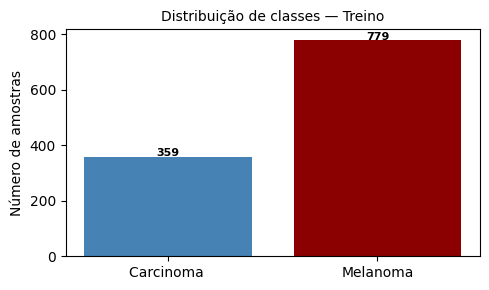

In [40]:
counts = [int((train_labels_full == 0).sum()), int((train_labels_full == 1).sum())]

plt.figure(figsize=(5, 3))
plt.bar(class_names_list, counts, color=['steelblue', 'darkred'])
for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=8)
plt.title('Distribuição de classes — Treino', fontsize = 10)
plt.ylabel('Número de amostras')
plt.tight_layout()
plt.show()

In [41]:
train_tensors_full = preprocess(train_imgs_full)
val_tensors_full   = preprocess(val_imgs_full)
test_tensors_full  = preprocess(test_imgs_full)

train_label_tensors_full = torch.tensor(train_labels_full, dtype=torch.long)
val_label_tensors_full   = torch.tensor(val_labels_full,   dtype=torch.long)
test_label_tensors_full  = torch.tensor(test_labels_full,  dtype=torch.long)

print("Train:", train_tensors_full.shape)
print("Val:  ", val_tensors_full.shape)
print("Test: ", test_tensors_full.shape)

Train: torch.Size([1138, 3, 28, 28])
Val:   torch.Size([163, 3, 28, 28])
Test:  torch.Size([326, 3, 28, 28])


In [42]:
n_class0 = int((train_labels_full == 0).sum())
n_class1 = int((train_labels_full == 1).sum())
total     = len(train_labels_full)

class_weights = torch.tensor([
    total / (2 * n_class0),
    total / (2 * n_class1)
], dtype=torch.float32)

print(f"Class weights — Carcinoma: {class_weights[0]:.3f} | Melanoma: {class_weights[1]:.3f}")

Class weights — Carcinoma: 1.585 | Melanoma: 0.730


In [43]:
class DermaDataModuleFull(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.hparams.update(hparams)

    def setup(self, stage=None):
        self.train_dataset = TensorDataset(train_tensors_full, train_label_tensors_full)
        self.val_dataset   = TensorDataset(val_tensors_full,   val_label_tensors_full)
        self.test_dataset  = TensorDataset(test_tensors_full,  test_label_tensors_full)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.hparams.batch_size,
                          shuffle=True,  num_workers=self.hparams.nworkers)

    def val_dataloader(self):
        return DataLoader(self.val_dataset,   batch_size=self.hparams.batch_size,
                          shuffle=False, num_workers=self.hparams.nworkers)

    def test_dataloader(self):
        return DataLoader(self.test_dataset,  batch_size=self.hparams.batch_size,
                          shuffle=False, num_workers=self.hparams.nworkers)

In [44]:
class TrainDermaFull(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

        derma_cnn_full = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = derma_cnn_full.fc.in_features
        derma_cnn_full.fc = nn.Linear(num_ftrs, hparams['nout'])
        self.model = derma_cnn_full

        self.loss     = nn.CrossEntropyLoss(weight=class_weights.to(device))
        self.accuracy = Accuracy(task='binary')

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss  = self.loss(y_hat, y)

        if mode == 'train':
            self.log('loss', loss, on_epoch=True, on_step=True)
            return loss
        elif mode == 'val':
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log('val_loss', loss,          on_epoch=True, on_step=False, prog_bar=True)
            self.log('val_acc',  self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step('train', train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step('val', val_batch)

    def configure_optimizers(self):
        return AdamW(self.model.parameters(),
                     lr=self.hparams.lr, weight_decay=self.hparams.wd)

In [45]:
hparams_derma_full = {
    'experiment_name': 'Derma_Full_ResNet18_v1',
    'max_epochs': 30,
    'batch_size': 32,
    'nworkers': 0,
    'nout': 2,
    'nin': 3,
    'lr': 3e-4,
    'wd': 1e-4,
    'cpu': False,
}

In [46]:
model_derma_full = TrainDermaFull(hparams_derma_full)
data_derma_full  = DermaDataModuleFull(hparams_derma_full)

os.makedirs('logs_derma_full', exist_ok=True)
checkpoint_callback_full = [ModelCheckpoint(
    dirpath='logs_derma_full',
    filename=hparams_derma_full['experiment_name'] + '-{epoch}-{val_acc:.2f}',
    monitor='val_acc',
    mode='max'
)]

trainer_derma_full = pl.Trainer(
    max_epochs=hparams_derma_full['max_epochs'],
    fast_dev_run=False,
    callbacks=checkpoint_callback_full,
    log_every_n_steps=1,
    deterministic=True
)

print('Hyperparameters:\n')
for k, v in hparams_derma_full.items():
    print(f'{k}: {v}')

trainer_derma_full.fit(model_derma_full, data_derma_full)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/laura/Documents/Unicamp/IA901/2026s1-pi05-cnn-Laur4vM/logs_derma_full exists and is not empty.

  | Name     | Type             | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model    | ResNet           | 11.2 M | train | 0    
1 | loss     | CrossEntropyLoss | 0      | train | 0    
2 | accuracy | BinaryAccuracy   | 0      | train | 0    
--------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.710 

Hyperparameters:

experiment_name: Derma_Full_ResNet18_v1
max_epochs: 30
batch_size: 32
nworkers: 0
nout: 2
nin: 3
lr: 0.0003
wd: 0.0001
cpu: False
                                                                           

/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/laura/Documents/Unicamp/IA901/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 36/36 [00:01<00:00, 28.69it/s, v_num=32, val_loss=0.413, val_acc=0.902]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 36/36 [00:01<00:00, 28.65it/s, v_num=32, val_loss=0.413, val_acc=0.902]


In [47]:
best_ckpt_full = sorted(glob('logs_derma_full/*.ckpt'))[-1]
print(f'Using model {best_ckpt_full}')

eval_model_full = TrainDermaFull.load_from_checkpoint(best_ckpt_full).eval().to(device)

data_derma_full.setup()
val_loader_full  = data_derma_full.val_dataloader()
test_loader_full = data_derma_full.test_dataloader()

y_true_val_full,  y_pred_val_full  = collect_2d_results(val_loader_full,  eval_model_full)
y_true_test_full, y_pred_test_full = collect_2d_results(test_loader_full, eval_model_full)

Using model logs_derma_full/Derma_Full_ResNet18_v1-epoch=23-val_acc=0.93.ckpt


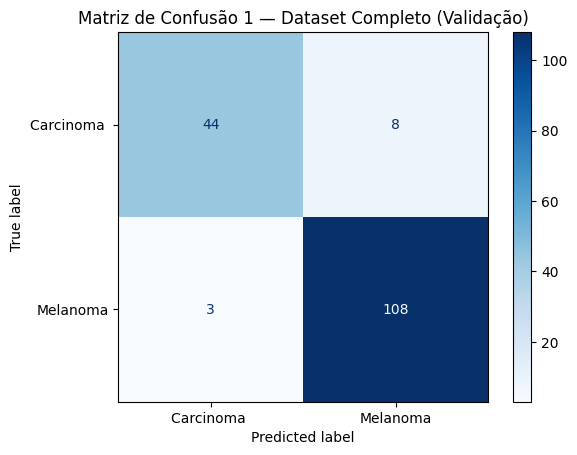

In [48]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_val_full, y_pred_val_full, labels=[0, 1]),
    display_labels=class_names_list
)
fig = disp.plot(cmap='Blues', ax=None).figure_

plt.title('Matriz de Confusão 1 — Dataset Completo (Validação)')
plt.show()

=== Validação — Dataset Completo (com class weights) ===
              precision    recall  f1-score   support

  Carcinoma        0.94      0.85      0.89        52
    Melanoma       0.93      0.97      0.95       111

    accuracy                           0.93       163
   macro avg       0.93      0.91      0.92       163
weighted avg       0.93      0.93      0.93       163

F1-score: 0.932
=== Teste — Dataset Completo (com class weights) ===
              precision    recall  f1-score   support

  Carcinoma        0.86      0.90      0.88       103
    Melanoma       0.95      0.93      0.94       223

    accuracy                           0.92       326
   macro avg       0.91      0.92      0.91       326
weighted avg       0.92      0.92      0.92       326

F1-score: 0.924


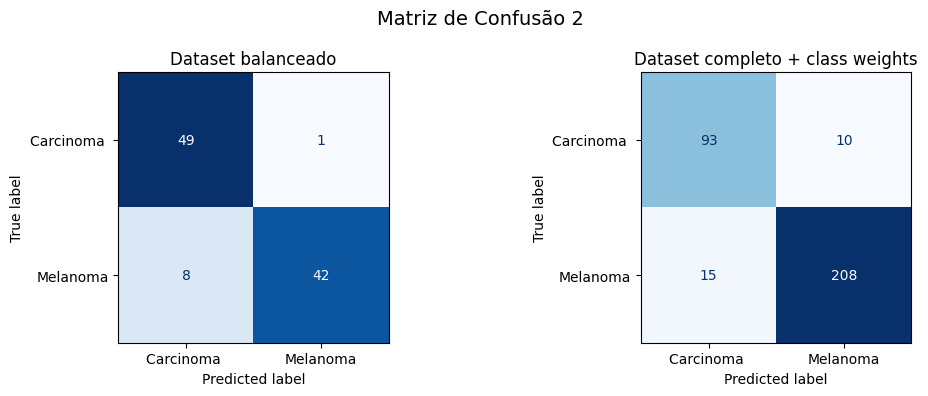

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

print('=== Validação — Dataset Completo (com class weights) ===')
print(classification_report(y_true_val_full, y_pred_val_full, target_names=class_names_list))
print(f'F1-score: {f1_score(y_true_val_full, y_pred_val_full, average="weighted"):.3f}')

print('=== Teste — Dataset Completo (com class weights) ===')
print(classification_report(y_true_test_full, y_pred_test_full, target_names=class_names_list))
print(f'F1-score: {f1_score(y_true_test_full, y_pred_test_full, average="weighted"):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_test, y_pred_test, labels=[0, 1]),
    display_labels=class_names_list
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Dataset balanceado')

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_test_full, y_pred_test_full, labels=[0, 1]),
    display_labels=class_names_list
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Dataset completo + class weights')

fig.suptitle('Matriz de Confusão 2', fontsize=14)

plt.tight_layout()
plt.show()

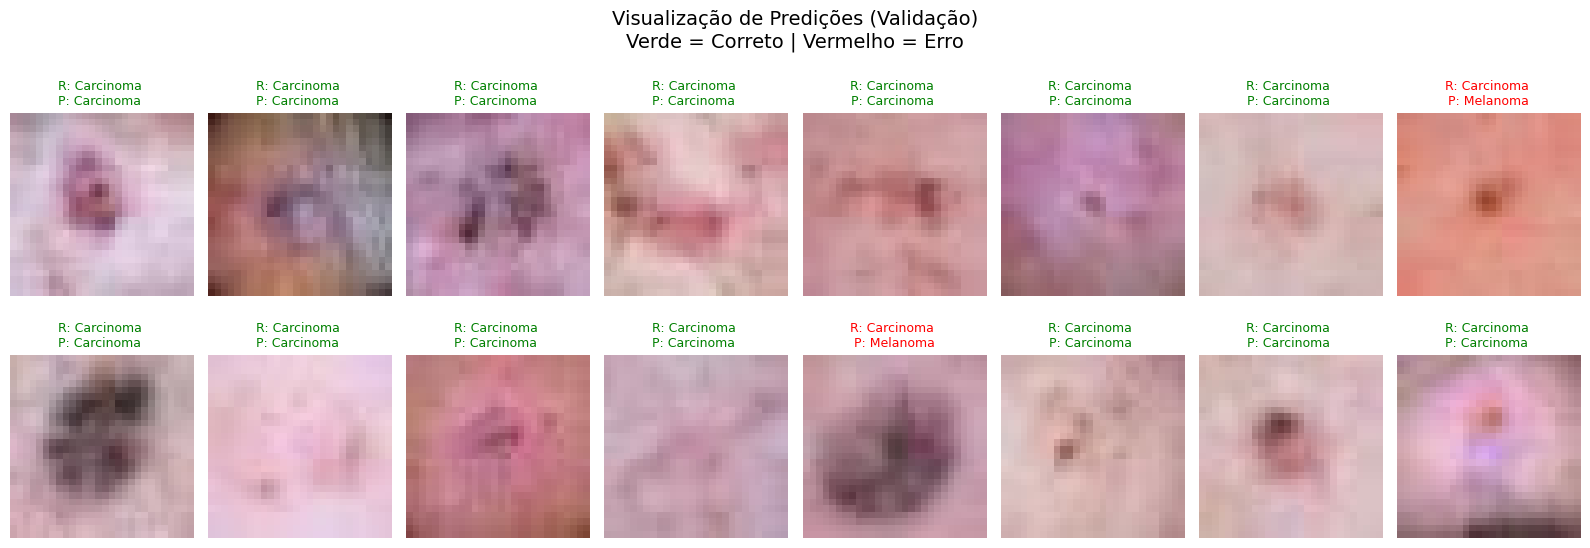

In [50]:
data_derma_full.hparams.batch_size = 16
val_loader_vis = data_derma_full.val_dataloader()

imgs_vis, labels_vis = next(iter(val_loader_vis))

eval_model_full.eval()
with torch.no_grad():
    logits = eval_model_full(imgs_vis.to(device))
    preds_vis = logits.argmax(dim=-1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 6))
axes = axes.flatten()

for i in range(16):
    img_show = val_imgs_full[i]   
    true_l = labels_vis[i].item()
    pred_l = preds_vis[i].item()
    color = 'green' if true_l == pred_l else 'red'
    
    axes[i].imshow(img_show)
    axes[i].set_title(f'R: {class_names_list[true_l]}\nP: {class_names_list[pred_l]}',
                      fontsize=9, color=color)
    axes[i].axis('off')

plt.suptitle('Visualização de Predições (Validação)\nVerde = Correto | Vermelho = Erro', fontsize=14)
plt.tight_layout()
plt.show()

### Metodologia
Como mencionado no enunciado, o dataset original possui múltiplas classes, mas foi simplificado para classificação binária, selecionando apenas duas categorias que são as imagens rotuladas como classe 1 e 4, como por exemplo, `train_indices_0_full = train_dataset_base.labels == 1` e `train_indices_1_full = train_dataset_base.labels == 4`. Após a seleção das imagens, foram concatenadas de modo a formar novos conjuntos de modo a conter apenas as categorias de interesse. Em seguida, foram criados novos vetores de rótulos para representar o problema no formato binário, então as imagens da primeira classe selecionada foram atribuídas ao rótulo _0_, enquanto as imagens da segunda classe foram atribuídas ao rótulo _1_.

Antes do treinamento do modelo, foi realizada uma análise da distribuição das classes no conjunto de treinamento para identificar se havia diferença significativa na quantidade de exemplos entre as duas categorias. Ter um conjunto de treinamento balanceado é importante principalmente em tarefas de classificação, porque redes tendem a aprender padrões dominantes da distribuição de dados. Quando há desbalanceamento entre classes, o modelo pode ficar enviesado para as classes mais frequentes.

Em seguida, as imagens passaram por uma etapa de pré-processamento, sendo convertidas para tensores compatíveis com o PyTorch e os rótulos também foram convertidos para tensores do tipo `torch.long`, formato requerido pela `CrossEntropyLoss`.

_Tratamento de desbalanceamento_
Como dito anteriormente, em casos de desbalanceamento de classes, o modelo tende a aprender um viés em favor da classe majoritária. A abordagem adotada nesse notebook, foi ponderar a `CrossEntropyLoss` com pesos inversamente proporcionais à frequência de cada classe:
$$w_c = \frac{N}{2 \cdot N_c}$$
Onde $N$ é o total de amostras de treino e $N_c$ é o número de amostras da classe $c$.
Ou seja, erros cometidos na classe minoritária geram uma penalização maior durante o treinamento, incentivando o modelo a aprender representações mais equilibradas para ambas as categorias.
Também seria viável usar o `WeightedRandomSampler`, que age na amostragem garantindo que ambas as classes apareçam com frequência similar a cada epoch, independentemente da distribuição original. A ponderação da loss foi preferida por ser mais simples de implementar e por preservar a distribuição natural dos dados no dataloader, o que pode ser vantajoso quando a classe majoritária contribui com exemplos adicionais genuinamente úteis para o aprendizado de features.

Foi usada a ResNet-18 pré-treinada no ImageNet, aplicando a estratégia de transfer learning. Para adaptar o modelo à tarefa específica deste trabalho, a camada totalmente conectada final da rede foi substituída por uma nova camada linear com duas saídas, correspondentes às duas classes da tarefa de classificação binária.
Durante o treinamento, foi utilizada a função de perda `CrossEntropyLoss`, incorporando os pesos de classe calculados anteriormente para lidar com o desbalanceamento do dataset. Como métrica principal de desempenho foi utilizada a acurácia, F1-score, mas também são incluidas precision e recall. O processo de otimização foi realizado utilizando o algoritmo AdamW, com taxa de aprendizado de 3x10^-4 e parâmetro de regularização weight decay igual a 1x10^-4. O treinamento foi executado por epoch=30 e com tamanho de lote batch size=32.
Por fim, também foi realizada uma entre diferentes configurações de treinamento, incluindo um cenário com dataset balanceado e outro utilizando o dataset completo com aplicação de pesos de classe, com o objetivo de analisar o impacto dessas estratégias no desempenho final do modelo.

### Análise dos resultados
A distribuição observada no conjunto de treino foi de 359 amostras de carcinoma e 779 de melanoma, o que representa um desbalanceamento de aproximadamente 1:2. Embora não seja extremo, esse desequilíbrio já é suficiente para introduzir viés em modelos que não consideram esse fator. Esse efeito pode ser observado na comparação entre as matrizes de confusão do dataset balanceado e do dataset completo com class weights. O modelo treinado com o dataset balanceado apresenta uma distribuição de erros mais simétrica (1 falso positivo e 8 falsos negativos), enquanto no dataset completo com class weights os erros aparecem de forma mais assimétrica (10 falsos positivos e 15 falsos negativos), porém em um volume muito maior de dados.

Na validação com o dataset completo, o modelo alcançou 93% de acurácia, com F1-score de 0,932. Observando o desempenho por classe, aparece um comportamento assimétrico esperado: recall de 0,85 para carcinoma e 0,97 para melanoma. Esse padrão sugere que, mesmo com a ponderação na função de perda, o modelo ainda encontra mais dificuldade para identificar casos de carcinoma. Uma possível explicação é que essa classe continua sub-representada em termos absolutos, além de que suas características visuais podem ser mais heterogêneas ou apresentar menor contraste, o que dificulta a identificação.

No conjunto de teste, a acurácia geral foi de 92%, com F1-score de 0,924. O recall para carcinoma aumentou para 0,90, enquanto o recall para melanoma ficou em 0,93, indicando que o modelo consegue generalizar de forma razoável. Considerando a importância do recall em aplicações clínicas, o valor de 0,90 para carcinoma, apesar de satisfatório, ainda significa que cerca de 10% dos casos reais não são detectados, algo que merece atenção em cenários clínicos reais.

A comparação entre o dataset balanceado e o dataset completo com class weights (Matriz de confusão 2) também revela um trade-off importante. O modelo treinado com dataset balanceado apresenta maior precisão relativa para carcinoma, com apenas 1 falso positivo, mas trabalha com um conjunto de dados reduzido, que pode não representar toda a variabilidade dentro da classe. Já o modelo treinado com o dataset completo e ponderação na loss se beneficia de um número maior de exemplos de melanoma, o que contribui para melhorar a generalização dessa classe, embora resulte em um aumento de falsos positivos para carcinoma (10 casos).

Na análise qualitativa das predições, a visualização dos resultados na validação mostra que os erros do modelo aparecem principalmente em imagens visualmente ambíguas. Em muitos casos, tratam-se de lesões de carcinoma com coloração rosada difusa e bordas pouco definidas, características que podem se parecer com lesões de melanoma.


**Referências**

Johnson, J.; Khoshgoftaar, T. [Survey on deep learning with class imbalance](https://link.springer.com/article/10.1186/s40537-019-0192-5)

Buda, M., Maki, A., & Mazurowski, M. A. [A systematic study of the class imbalance problem in convolutional neural networks](https://www.sciencedirect.com/science/article/pii/S0893608018302107) 

Tschandl, P., Rosendahl, C., & Kittler, H. [The HAM10000 dataset: a large collection of multi-source dermatoscopic images of common pigmented skin lesions](https://www.nature.com/articles/sdata2018161)

Brinker et al. [Deep learning outperformed 136 of 157 dermatologists in a head-to-head dermoscopic melanoma image classification task](https://pubmed.ncbi.nlm.nih.gov/30981091/)